# Pytorch Force Inference Code for Overdamped Persistent Dynamics

This notebook demonstrates how to use the refactored `GNN_inference` module step-by-step.

This is an adaptation of Billie's force inference code for overdamped persistent cell dynamics, converting it from tensorflow to pytorch for experimental data.

In [1]:
# Enable autoreload so module changes are automatically reloaded
%load_ext autoreload
%autoreload 2

# Import everything from the module
import sys
sys.path.append('..')

import importlib
import torch
import torch.nn as nn

import torch_inference_sims
importlib.reload(torch_inference_sims)
from torch_inference_sims import *
import functorch
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# auto-reload the module

clrs = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
clrs = ['#bfd3e6','#9ebcda','#8c96c6','#8c6bb1','#88419d','#6e016b','#bfd3e6','#9ebcda','#8c96c6','#8c6bb1','#88419d','#6e016b']
clrs0 = ['#cc4c02','#6a51a3','#78c679','#bfd3e6']
cmap = sns.color_palette("viridis", as_cmap=True)


In [2]:
def force_environment_NonLinear(x, y, kappa_x, kappa_y, x_0, y_0, alpha, L=1.0):
    dx = x - x_0
    dy = y - y_0
    # alpha=1 → linear spring, alpha>1 → increasingly nonlinear
    Fx = -kappa_x * np.sign(dx) * (np.abs(dx)/L)**(alpha) * L
    Fy = -kappa_y * np.sign(dy) * (np.abs(dy)/L)**(alpha) * L
    return np.array([Fx, Fy])

## Create and Train Model


In [3]:
class ForceGNN(nn.Module):
    """
    Graph Neural Network for learning force decomposition.
    
    Forces are decomposed into:
    - F_env: Environmental/external forces (position-dependent, uses node_features[:, :2])
    - F_r: Pairwise interaction forces (distance-dependent)
    - Memory/drag term using Jacobian-vector product of F_env and tau_raw
    
    Node features: [x, y, vx, vy, type] - positions, velocities, and particle type
    """
    
    def __init__(self, hidden_dim=32, tau_init=1.0):
        super(ForceGNN, self).__init__()

        self.r_mean = 0.0
        self.r_std  = 1.0
        self.y_mean = np.array([0.0, 0.0], dtype=np.float32)
        self.y_std  = np.array([1.0, 1.0], dtype=np.float32)
        self.x_mean = np.array([0.0, 0.0], dtype=np.float32)
        self.x_std  = float(1.0)
        self.env_net = nn.Sequential(
            nn.Linear(2, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, 2)
        )
        
        # self.interaction_net = nn.Sequential(
        #     nn.Linear(1, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, 1)
        # )
        
        # self.env_net = nn.Sequential(
        #     nn.Linear(2, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, 2)
        # )

        # self.env_net = nn.Sequential(
        #     nn.Linear(2, hidden_dim),
        #     nn.SiLU(),                          # SiLU == Swish
        #     nn.Linear(hidden_dim, hidden_dim),
        #     nn.SiLU(),
        #     nn.Linear(hidden_dim, hidden_dim),
        #     nn.SiLU(),
        #     nn.Linear(hidden_dim, 2)
        # )
        # self.env_net = nn.Sequential(
        #     nn.Linear(2, hidden_dim),
        #     nn.SiLU(),                          # SiLU == Swish
        #     nn.LayerNorm(hidden_dim),
        #     nn.Linear(hidden_dim, hidden_dim),
        #     nn.SiLU(),
        #     nn.LayerNorm(hidden_dim),
        #     nn.Linear(hidden_dim, hidden_dim),
        #     nn.SiLU(),
        #     nn.Linear(hidden_dim, 2)
        # )

        # self.interaction_net = nn.Sequential(
        #     nn.Linear(1, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, 1)
        # )

        # Learnable memory timescale
        self.tau_raw = nn.Parameter(
            torch.tensor(tau_init, dtype=torch.float32)
        )

    def _jvp(self, positions, velocities):
        """
        Compute Jacobian-vector product (∂F_env/∂x) · v using
        forward-mode AD via torch.func.jvp.
        
        Parameters:
        -----------
        positions  : (N, 2) position tensor
        velocities : (N, 2) velocity tensor (the tangent vector)
        
        Returns:
        --------
        Jv : (N, 2) JVP result
        """

        def f(pos):
            return self.env_net(pos)

        _, Jv = torch.func.jvp(f, (positions,), (velocities,))
        return Jv

    def forward(self, node_features, edge_indices, edge_features, return_components=False):
        """
        Forward pass of the model.
        
        Parameters:
        -----------
        node_features  : Tensor (N, 5) [x, y, vx, vy, type]
        edge_indices   : Tensor (2, E) edge connections
        edge_features  : Tensor (E, 3) [r, dx/r, dy/r]
        return_components : bool
            If True, return individual force components
        
        Returns:
        --------
        F_total or tuple of (F_total, F_r_aggregated, F_drag, F_env)
        """
        _y = getattr(self, "y_std", 1.0)
        y_std = float(np.asarray(_y).flat[0]) if np.ndim(_y) != 0 else float(_y)
        if y_std == 0.0:
            y_std = 1.0
        
        _x = getattr(self, "x_std", 1.0)
        x_std = float(np.asarray(_x).flat[0]) if np.ndim(_x) != 0 else float(_x)
        if x_std == 0.0:
            x_std = 1.0

        # Extract positions and velocities
        positions  = node_features[:, :2]
        velocities = node_features[:, 2:4]

        # Environmental force
        F_env = self.env_net(positions)

        # # Pairwise interaction force
        # if edge_indices.shape[1] > 0:
        #     edge_distances  = edge_features[:, 0:1]
        #     F_r_scalar      = self.interaction_net(edge_distances)
        #     edge_unit_vectors = edge_features[:, 1:3]
        #     F_r_vector      = F_r_scalar*edge_unit_vectors

        #     target_indices  = edge_indices[1, :]
        #     N = node_features.shape[0]
        #     F_r_aggregated  = torch.zeros(N, 2, dtype=node_features.dtype, device=node_features.device)
        #     F_r_aggregated.scatter_add_(
        #         0,
        #         target_indices.long().unsqueeze(1).expand_as(F_r_vector),
        #         F_r_vector
        #     )
        # else:
        #     F_r_aggregated = torch.zeros_like(F_env)

        # (∂F_env/∂x)·v
        #Jv = self._jvp(positions, velocities)

        Jv = self._jvp(positions, velocities)
        vel_term = self.tau_raw*Jv/ x_std  - (1.0/self.tau_raw)*velocities / y_std #self.tau_raw*Jv/ x_std 
        F_drag = vel_term * (2/3)

        # Total force
        F_total = F_drag  + F_env #+ F_r_aggregated

        if return_components:
            return F_total, F_drag, F_env #, F_r_aggregated
        return F_total

In [4]:
def train_model(
    model,
    train_data,
    val_data,
    far_field_reg=0.0,
    far_field_r=70,
    max_r=100.0,
    K_far=1000,
    num_epochs=100,
    learning_rate=1e-3,
    verbose=True,
    eval_before_update=True,
    include_far_field_in_val=False,
    far_field_seed=0,
):
    """
    Train ForceGNN with consistent loss computation and flexible evaluation timing.

    eval_before_update=True:
        reports train/val losses computed on the SAME weights at epoch start.
    eval_before_update=False:
        reports train/val losses after training updates (standard behavior).
    """

    #optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    optimizer = torch.optim.Adam([
        {'params': [p for n, p in model.named_parameters() if 'tau_raw' not in n],
        'lr': learning_rate},
        {'params': [model.tau_raw], 
        'lr': learning_rate * 20,   # tau explores 10x faster initially
        'name': 'tau_raw'}
    ], lr=learning_rate)

    # Cosine annealing decays tau_raw's lr faster than the network
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=learning_rate * 0.01
    )

    # Normalization attachment
    if len(train_data) > 0 and isinstance(train_data[0], dict):
        dp0 = train_data[0]
        if 'r_mean' in dp0 and 'r_std' in dp0:
            model.r_mean = float(dp0['r_mean'])
            model.r_std  = float(dp0['r_std']) or 1.0
        if 'y_mean' in dp0 and 'y_std' in dp0:
            model.y_mean = np.array(dp0['y_mean'], dtype=np.float32)
            model.y_std  = float(dp0['y_std']) or 1.0
        if 'x_mean' in dp0 and 'x_std' in dp0:
            model.x_mean = np.array(dp0['x_mean'], dtype=np.float32)
            model.x_std  = float(dp0['x_std']) or 1.0
    
    # Loss helpers
    def masked_mse(pred, targ, mask):
        """pred, targ: (N, 2); mask: (N,)"""
        mask = mask.float()
        num = mask.sum()
        if num == 0:
            return torch.tensor(0.0, device=pred.device), torch.tensor(0.0, device=pred.device)
        mask_exp = mask.unsqueeze(1)
        se = (pred - targ).pow(2) * mask_exp
        mse = se.sum() / (num * 2.0)
        return mse, num

    def far_field_penalty(r_far_phys):
        """r_far_phys: (K, 1) in physical units"""
        lam = float(far_field_reg)
        if lam == 0.0:
            return torch.tensor(0.0, device=next(model.parameters()).device)

        r_mean = float(getattr(model, "r_mean", 0.0))
        r_std  = float(getattr(model, "r_std",  1.0))
        if r_std == 0.0:
            r_std = 1.0

        r_far_norm = (r_far_phys - r_mean)/r_std
        F_far = model.interaction_net(r_far_norm)
        return lam*F_far.pow(2).mean()

    def compute_loss_on_dataset(dataset, r_far_phys, include_far):
        total_loss  = 0.0
        total_mse   = 0.0
        total_reg   = 0.0
        total_nodes = 0.0
        n_frames_used = 0

        model.eval()
        with torch.no_grad():
            for dp in dataset:
                if 'mask' in dp and np.sum(dp['mask']) == 0:
                    continue

                pred = model(torch.tensor(dp['nodes']), torch.tensor(dp['edges']), torch.tensor(dp['edge_feat']))
                targ = torch.tensor(dp['targets']).float()

                if 'mask' in dp:
                    mask = torch.tensor(dp['mask'])
                    if not isinstance(mask, torch.Tensor):
                        mask = torch.tensor(mask, dtype=torch.float32, device=pred.device)
                    mse, num = masked_mse(pred, targ, mask)
                    if num.item() == 0:
                        continue
                else:
                    mse = (pred - targ).pow(2).mean()
                    num = torch.tensor(float(pred.shape[0]), device=pred.device)

                reg  = far_field_penalty(r_far_phys) if include_far else torch.tensor(0.0, device=pred.device)
                loss = mse + reg

                n = num.item()
                total_loss  += loss.item() * n
                total_mse   += mse.item()  * n
                total_reg   += reg.item()  * n
                total_nodes += n
                n_frames_used += 1

        if total_nodes == 0:
            return np.nan, np.nan, np.nan, 0, 0

        return (
            total_loss  / total_nodes,
            total_mse   / total_nodes,
            total_reg   / total_nodes,
            int(total_nodes),
            n_frames_used,
        )

    # Training
    def train_step(dp, r_far_phys):
        model.train()
        optimizer.zero_grad()

        pred = model(torch.tensor(dp['nodes']), torch.tensor(dp['edges']), torch.tensor(dp['edge_feat']))
        targ = torch.tensor(dp['targets']).float()

        if 'mask' in dp:
            mask = torch.tensor(dp['mask'])
            if not isinstance(mask, torch.Tensor):
                mask = torch.tensor(mask, dtype=torch.float32, device=pred.device)
            mse, num = masked_mse(pred, targ, mask)
        else:
            mse = (pred - targ).pow(2).mean()
            num = torch.tensor(float(pred.shape[0]), device=pred.device)

        reg  = far_field_penalty(r_far_phys)
        loss = mse + reg

        loss.backward()
        optimizer.step()

        return loss, mse, reg, num

    history = {
        "train_loss": [], "val_loss": [],
        "train_mse":  [], "val_mse":  [],
        "train_reg":  [], "val_reg":  [],
        "tau_raw":    [],
    }

    if verbose:
        print(f"Training for {num_epochs} epochs...")
        print("=" * 60)

    device = next(model.parameters()).device

    for epoch in range(num_epochs):
        r_far_phys = far_field_r + (max_r - far_field_r)*torch.rand(
            K_far, 1, dtype=torch.float32, device=device,
            generator=torch.Generator(device=device).manual_seed(far_field_seed + epoch)
        )
        # Evaluate BEFORE updates
        if eval_before_update:
            trL, trM, trR, trN, trF = compute_loss_on_dataset(train_data, r_far_phys, include_far=True)
            vaL, vaM, vaR, vaN, vaF = compute_loss_on_dataset(val_data,   r_far_phys, include_far=include_far_field_in_val)
        else:
            trL = trM = trR = vaL = vaM = vaR = None

        # Train one epoch
        total_loss  = 0.0
        total_mse   = 0.0
        total_reg   = 0.0
        total_nodes = 0.0

        for dp in train_data:
            if 'mask' in dp and np.sum(dp['mask']) == 0:
                continue

            loss, mse, reg, num = train_step(dp, r_far_phys)
            n = num.item()
            if n == 0:
                continue

            total_loss  += loss.item() * n
            total_mse   += mse.item()  * n
            total_reg   += reg.item()  * n
            total_nodes += n

        train_loss_after = (total_loss / total_nodes) if total_nodes > 0 else np.nan
        train_mse_after  = (total_mse  / total_nodes) if total_nodes > 0 else np.nan
        train_reg_after  = (total_reg  / total_nodes) if total_nodes > 0 else np.nan
        
        # Evaluate AFTER updates
        if not eval_before_update:
            trL, trM, trR, _, _ = compute_loss_on_dataset(train_data, r_far_phys, include_far=True)
            vaL, vaM, vaR, _, _ = compute_loss_on_dataset(val_data,   r_far_phys, include_far=include_far_field_in_val)
        scheduler.step()
        history["train_loss"].append(trL)
        history["val_loss"].append(vaL)
        history["train_mse"].append(trM)
        history["val_mse"].append(vaM)
        history["train_reg"].append(trR)
        history["val_reg"].append(vaR)
        history["tau_raw"].append(
            model.tau_raw.item() if hasattr(model, 'tau_raw') else np.nan
        )

        if verbose and (epoch % 10 == 0 or epoch == num_epochs - 1):
            tau_lr = optimizer.param_groups[1]['lr']
            #print(f"... Tau_raw={tau_val:.6f}, Tau_lr={tau_lr:.6f}")
            timing = "PRE" if eval_before_update else "POST"
            tau_val = model.tau_raw.item() if hasattr(model, 'tau_raw') else float('nan')
            print(
                f"Epoch {epoch:3d} [{timing}-update metrics]: "
                f"Train L={trL:.6f} (mse={trM:.6f}, reg={trR:.6f}) | "
                f"Val L={vaL:.6f} (mse={vaM:.6f}, reg={vaR:.6f}) | "
                f"Train-step avg(after)={train_loss_after:.6f} | "
                f"Tau_raw={tau_val:.6f}, Tau_lr={tau_lr:.6f}"
            )

    return model, history

In [5]:
def create_model(hidden_dim=32, tau_init=1.0):
    """
    Create a ForceGNN model.
    
    Parameters:
    -----------
    hidden_dim : int
        Hidden dimension for neural network layers
    
    Returns:
    --------
    ForceGNN
        Initialized model
    """
    model = ForceGNN(hidden_dim=hidden_dim, tau_init=tau_init)
    print(f"ForceGNN model created with hidden_dim={hidden_dim}")
    return model

In [6]:
# import pickle
# save_path = Path("/Users/billiemeadowcroft/Dropbox/PostDocCode/SeanData/for_billie/dataIN/")  # or your scratch dir
# nameSave_DataIN = "FenvOnly_tau1_kappa0.5.pkl"

# with open(save_path / nameSave_DataIN, "rb") as f:
#     data_loaded = pickle.load(f)

# dataset = data_loaded["dataset"]
# meta = data_loaded["meta"]
# train_frac = 0.7
# val_frac = 0.3
# test_frac = 0.0
# train_data_, val_data_, test_data_, all_data_ = split_dataset(dataset)

        

In [108]:
# Prepare dataset with graph structure
datadir = "//Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/PersistentCells/Data_CSVs/"
save_path = Path("/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/PersistentCells/dataIN/")
datasave = "/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/PersistentCells/models/"
#datadir = "/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/Data_CSVs/Simulations/LimitsLibrary/"

temp = 0.1 #0.1
numframes = 300
seed = 1
tau_mem0=10
frame = 100 #200
NumEpochs = 100
kappa0 = 1.0 #0.3
gamma0 = 1 #3 #1/20
epsilon = 0.0
alpha = 1.5 #,2.5] #,2.0,2.5
delta_t = 0.001

folder = '/NonLinearForce/'
dataname = f"output_Persistent_alpha{alpha}_epsilon{epsilon}_frame{frame}kappa{kappa0}_Gamma{gamma0}_Tau{tau_mem0}Sig1.1N100seed{seed}_Temp{temp}_NumFrames{numframes}.csv"
AltUD_Data = '/Users/billiemeadowcroft/Dropbox/PostDocCode/Github_SFI/GNN_Inference/ForSean/Data_CSVs/Simulations/LimitsLibrary/'
name = 'outputTestingGamma_NoTrap_kappa0.01_temp0.1_trajlen300_dt0.001_N200_seed1_damp1frame20.csv'

dataname = "outputVariableNodes_kappa0.2_temp0.1_trajlen300_dt0.01_N20_seed1_damp50frame10.csv" #for sure variable nodes
datadir = '/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/Data_CSVs/Simulations/'

dataname = 'outputTestingGamma_NoTrap_kappa0.01_temp0.1_trajlen300_dt0.001_N200_seed1_damp1frame20.csv'
datadir = '/Users/billiemeadowcroft/Dropbox/PostDocCode/Github_SFI/GNN_Inference/ForSean/Data_CSVs/Simulations/LimitsLibrary/'
#datadir = '/home/skomura/Folders/code/StochasticForceInference/GNN_Inference/ForSean/'
#data = load_data(datadir, dataname)

dataname = "outputVariableNodes_kappa0.2_temp0.1_trajlen300_dt0.01_N20_seed1_damp50frame10.csv" #for sure variable nodes
datadir = '//Users/billiemeadowcroft/Dropbox/PostDocCode/Github_SFI/GNN_Inference/ForSean/'


dataname = "output_Persistent_alpha1.3_epsilon0.0_frame100kappa0.5_Gamma1_Tau10Sig1.1N100seed1_Temp0.1_NumFrames300.csv"
dataname = "output_Persistent_alpha1.5_epsilon0.0_frame100kappa0.5_Gamma1_Tau10Sig1.1N100seed1_Temp0.1_NumFrames300.csv"
datadir='/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/PersistentCells/Data_CSVs/NonLinearForce/'
data = load_data(datadir, dataname)

#data = load_data(AltUD_Data, name)

dt = delta_t*frame
T_weak = False
T_Naive = True
tau = 16
print("length of data: ", len(data))
print("Total unique particles: ", len(data['particle'].unique()))
print("for naive derivative, should be losing 2x the number of particles",len(data)-len(data['particle'].unique())*2)
min_frame = data['frame'].min()
max_frame = data['frame'].max()
#data = data[data['frame'] > max_frame-140]
data_clean = calculate_derivatives(data, dt=dt,weak_form = T_weak,naive_form = T_Naive,tau = tau)
dataset_ = prepare_dataset(data_clean, cutoff=3.0, max_frames=700,use_neighbor_list=False)
train_data, val_data, test_data, __ = split_dataset(dataset_)

Data loaded: (29900, 7)
Columns: ['frame', 'particle', 'type', 'x', 'y', 'z', 'sumForce']
Number of frames: 299
length of data:  29900
Total unique particles:  100
for naive derivative, should be losing 2x the number of particles 29700
Calculating derivatives...
Processing 100 particles...
Calculating naïve derivatives...
Acceleration statistics:
  ax: mean=0.001, std=1.123
  ay: mean=0.004, std=1.128
Preparing dataset from 299 frames...
processing frame  0.0
processing frame  1.0
processing frame  2.0
processing frame  3.0
processing frame  4.0
processing frame  5.0
processing frame  6.0
processing frame  7.0
processing frame  8.0
processing frame  9.0
processing frame  10.0
processing frame  11.0
processing frame  12.0
processing frame  13.0
processing frame  14.0
processing frame  15.0
processing frame  16.0
processing frame  17.0
processing frame  18.0
processing frame  19.0
processing frame  20.0
processing frame  21.0
processing frame  22.0
processing frame  23.0
processing frame

In [109]:
# Create model
model = create_model(hidden_dim=64, tau_init=2)

# Train model
Epochs = 300
far_field_strength = 0.0
far_field_r = 3.0
max_r = 4.0
K_far = 1
model, history = train_model(model,train_data,val_data,far_field_reg=far_field_strength,far_field_r=far_field_r,max_r=max_r,K_far=K_far,num_epochs=Epochs,learning_rate=1e-3,verbose=True,include_far_field_in_val=False,far_field_seed=1)

#model, history = train_model(model, train_data, val_data, num_epochs=100)


ForceGNN model created with hidden_dim=64
Training for 300 epochs...
Epoch   0 [PRE-update metrics]: Train L=1.018643 (mse=1.018643, reg=0.000000) | Val L=1.020923 (mse=1.020923, reg=0.000000) | Train-step avg(after)=0.976555 | Tau_raw=1.504111, Tau_lr=0.019999
Epoch  10 [PRE-update metrics]: Train L=0.973677 (mse=0.973677, reg=0.000000) | Val L=0.978722 (mse=0.978722, reg=0.000000) | Train-step avg(after)=0.973790 | Tau_raw=1.489882, Tau_lr=0.019934
Epoch  20 [PRE-update metrics]: Train L=0.973464 (mse=0.973464, reg=0.000000) | Val L=0.978811 (mse=0.978811, reg=0.000000) | Train-step avg(after)=0.973608 | Tau_raw=1.493080, Tau_lr=0.019759
Epoch  30 [PRE-update metrics]: Train L=0.973213 (mse=0.973213, reg=0.000000) | Val L=0.978601 (mse=0.978601, reg=0.000000) | Train-step avg(after)=0.973412 | Tau_raw=1.502358, Tau_lr=0.019478
Epoch  40 [PRE-update metrics]: Train L=0.972867 (mse=0.972867, reg=0.000000) | Val L=0.978579 (mse=0.978579, reg=0.000000) | Train-step avg(after)=0.972955 | 

In [103]:
temp = 0.1 #0.1
numframes = 300 #300
seed = 1
tau_mem0=10
frame = 100
NumEpochs = 100
#output_Persistent_alpha2.0_epsilon0_frame100kappa0_Gamma3_Tau1Sig1.1N100seed1_Temp0.1_NumFrames300
kappa0 = 0.5
gamma0 = 1
A = kappa0/(gamma0*tau_mem0)
B = -(np.divide(kappa0,gamma0)+np.divide(1,tau_mem0))
C = 1
# tau is solution of A*tau + B*tau + C = 0
tau_sol1 = np.divide(-B + np.sqrt(B**2 - 4*A*C),2*A)
tau_sol2 = np.divide(-B - np.sqrt(B**2 - 4*A*C),2*A)
print("tau_sol1",tau_sol1)
print("tau_sol2",tau_sol2)


tau_sol1 10.0
tau_sol2 2.0


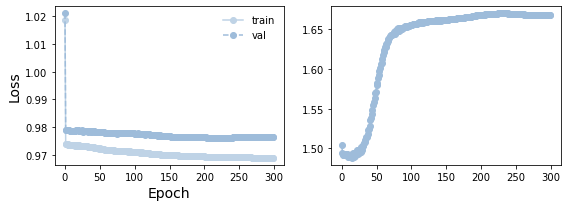

In [111]:
# Plot training history
tau_mem0=10
gamma0=1

fig,ax  = plt.subplots(1,2,figsize = (8,3))
ax[0].plot(history['train_loss'],color = clrs[0],linestyle = '-',label = 'train',marker = 'o')
ax[0].plot(history['val_loss'],color = clrs[1],linestyle = '--',label = 'val',marker = 'o')
ax[1].plot(history['tau_raw'],color = clrs[1],linestyle = '--',label = 'tau',marker = 'o')
#ax[1].plot([0,len(history['tau_raw'])],[tau_mem0,tau_mem0],color = 'black',linestyle = '--',label = r"True force gradient $\nabla_x F$")
ax[0].legend(frameon = False)
ax[0].set_xlabel('Epoch',fontsize = 14)
ax[0].set_ylabel('Loss',fontsize = 14)
fig.tight_layout()

In [65]:
def get_force_environment(model, x, y):
    if not hasattr(model, 'env_net') or model.env_net is None:
        raise AttributeError(
            "This model does not have an env_net (F_env component). "
            "The model was trained without environmental forces."
        )

    x_mean = np.array(getattr(model, "x_mean", [0.0, 0.0]), dtype=np.float32)
    x_std  = float(getattr(model, "x_std", 1.0))
    if x_std == 0.0:
        x_std = 1.0

    # Normalise query position
    x_norm = (float(x) - float(x_mean[0])) / x_std
    y_norm = (float(y) - float(x_mean[1])) / x_std

    model.eval()
    with torch.no_grad():
        inp = torch.tensor([[x_norm, y_norm]], dtype=torch.float32,
                           device=next(model.parameters()).device)
        F_env_norm = model.env_net(inp).cpu().numpy()[0, :]

    # De-normalise output to physical units
    _y = getattr(model, "y_std", 1.0)
    y_std = float(np.asarray(_y).flat[0]) if np.ndim(_y) != 0 else float(_y)
    if y_std == 0.0:
        y_std = 1.0

    return y_std * F_env_norm

Loaded config from: //Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/PersistentCells/PyTorch/models/NonLinearSweep/modelGradF_OD_persistent_pairwise_alpha2.0_epsilon0.0_tauInit10_seed3_kappa0.5_Gamma1_Tau10Sig1.1N100seed3_Temp0.1_NumFrames300_Epochs100_3Tanh_config.json  (hidden_dim=64)
Weights loaded from: //Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/PersistentCells/PyTorch/models/NonLinearSweep/modelGradF_OD_persistent_pairwise_alpha2.0_epsilon0.0_tauInit10_seed3_kappa0.5_Gamma1_Tau10Sig1.1N100seed3_Temp0.1_NumFrames300_Epochs100_3Tanh.pt
Normalisation restored: r_mean=1.75026, r_std=0.771113
  hidden_dim=64, tau=9.529212
Data loaded: (29900, 7)
Columns: ['frame', 'particle', 'type', 'x', 'y', 'z', 'sumForce']
Number of frames: 299
0.5
-2.440931962165479
-1.627287974776986
i 0
i 1
i 2
i 3
i 4
i 5
i 6
i 7
i 8
i 9


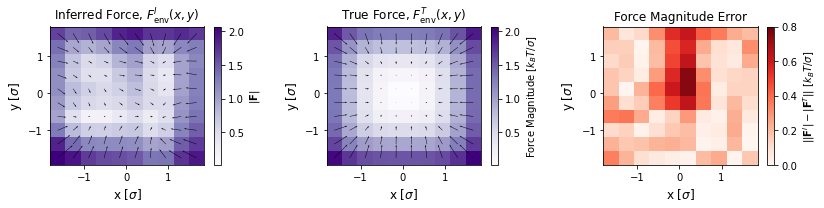

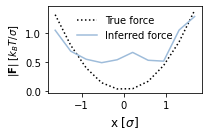

In [101]:
kappa0 = 0.5
alpha=2.0 #1.5
tau_mem0 = 10
seed=3
datasave = '//Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/PersistentCells/PyTorch/models/NonLinearSweep/'

dataname = f"output_Persistent_alpha{alpha}_epsilon{epsilon}_frame{frame}kappa{kappa0}_Gamma{gamma0}_Tau{tau_mem0}Sig1.1N100seed{seed}_Temp{temp}_NumFrames{numframes}.csv"
name = f"modelGradF_OD_persistent_pairwise_alpha{alpha}_epsilon{epsilon}_tauInit{np.round(tau_mem0,1)}_seed{seed}_kappa{kappa0}_Gamma{gamma0}_Tau{tau_mem0}Sig1.1N100seed{seed}_Temp{temp}_NumFrames{numframes}_Epochs{NumEpochs}_4Tanh"

#name = f"modelGradF_OD_persistent_pairwise_alpha{alpha}_epsilon{epsilon}_tauInit{np.round(tau_mem0,1)}_seed{seed}_kappa{kappa0}_Gamma{gamma0}_Tau{tau_mem0}Sig1.1N100seed{seed}_Temp{temp}_NumFrames{numframes}_Epochs{NumEpochs}_frame50_3Tanh"
tau_mem0 = 10
#name = f"model-NO-GradF_OD_persistent_pairwise_alpha{alpha}_epsilon{epsilon}_tauInit{np.round(tau_mem0,1)}_seed{seed}_kappa{kappa0}_Gamma{gamma0}_Tau{tau_mem0}Sig1.1N100seed{seed}_Temp{temp}_NumFrames{numframes}_Epochs{NumEpochs}_Simple3Elus"
#loaded_model = load_model(datasave+folder+name+'.h5', hidden_dim=64) #,  save_format='weights')
#loaded_model = load_model(datasave+name, hidden_dim=64)
#data = load_data(datadir+folder, dataname)
name = f"modelGradF_OD_persistent_pairwise_alpha{alpha}_epsilon{epsilon}_tauInit{np.round(tau_mem0,1)}_seed{seed}_kappa{kappa0}_Gamma{gamma0}_Tau{tau_mem0}Sig1.1N100seed{seed}_Temp{temp}_NumFrames{numframes}_Epochs{NumEpochs}_3Tanh_Fenv"
name = f"modelGradF_OD_persistent_pairwise_alpha{alpha}_epsilon{epsilon}_tauInit{np.round(tau_mem0,1)}_seed{seed}_kappa{kappa0}_Gamma{gamma0}_Tau{tau_mem0}Sig1.1N100seed{seed}_Temp{temp}_NumFrames{numframes}_Epochs{NumEpochs}_3Tanh"
loaded_model = load_model(datasave+name, hidden_dim=64)
#dataname = "output_Persistent_alpha1.3_epsilon0.0_frame100kappa0.5_Gamma1_Tau10Sig1.1N100seed1_Temp0.1_NumFrames300.csv"
dataname = f"output_Persistent_alpha{alpha}_epsilon{epsilon}_frame{frame}kappa{kappa0}_Gamma{gamma0}_Tau{tau_mem0}Sig1.1N100seed{seed}_Temp{temp}_NumFrames{numframes}.csv"
dataname = "output_Persistent_alpha1.5_epsilon0.0_frame100kappa0.5_Gamma1_Tau10Sig1.1N100seed1_Temp0.1_NumFrames300.csv"
#datadir='/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/PersistentCells/Data_CSVs/NonLinearForce/'
#data = load_data(datadir, dataname)
dataname = "output_Persistent_alpha2.0_epsilon0.0_frame100kappa0.5_Gamma1_Tau10Sig1.1N100seed3_Temp0.1_NumFrames300.csv"
datadir='/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/PersistentCells/Data_CSVs/NonLinearForce/'
data = load_data(datadir, dataname)
print(kappa0)
print(np.min(data['x']))


kappa_x,kappa_y = kappa0,kappa0
x_0,y_0 = 0,0
L=1
center = np.array([0,0])
x_arr = np.linspace(data['x'].min()/1.5,data['x'].max()/1.5,10)
y_arr = np.linspace(data['y'].min()/1.5,data['y'].max()/1.5,10)
print(x_arr[0])
X, Y = np.meshgrid(x_arr, y_arr, indexing='ij')
F_env_infer = np.zeros((len(x_arr),len(y_arr),2))
F_env_true = np.zeros((len(x_arr),len(y_arr),2))
for i,x in enumerate(x_arr):
    print("i",i)
    for j,y in enumerate(y_arr):
        F_env_infer[i,j,:] = get_force_environment(model , x, y)*tau_mem0*gamma0
        F_env_true[i,j] = force_environment_NonLinear(x,y,kappa_x,kappa_y,x_0,y_0,alpha,L) #arbitrary_force(x,y,kappa_y,center,A_x,L_x) #
F_mag = np.linalg.norm(F_env_infer, axis=2)  # shape (len(x_arr), len(y_arr))
F_mag_true = np.linalg.norm(F_env_true, axis=2)  # shape (len(x_arr), len(y_arr))


# Count datapoints per bin
counts, x_edges, y_edges = np.histogram2d(
    data['x'], data['y'],
    bins=[len(x_arr), len(y_arr)],
    range=[[x_arr[0], x_arr[-1]], [y_arr[0], y_arr[-1]]]
)
# counts[i, j] = number of datapoints in bin (i, j)
# Mask bins with <= 10 datapoints
sparse_mask = counts <= 10  # shape (len(x_arr), len(y_arr))

F_mag_masked = np.where(sparse_mask, np.nan, F_mag)
F_mag_true_masked = np.where(sparse_mask, np.nan, F_mag_true)

# Create coordinate grid (note indexing='ij' to match F_env_infer[i,j,:])
X, Y = np.meshgrid(x_arr, y_arr, indexing='ij')

fig,ax  = plt.subplots(1,3,figsize = (7.8*1.5,3))


# pcm = ax[0].pcolormesh(X, Y, F_mag, shading='auto', cmap='Purples',vmin =np.min(F_mag_true),vmax = np.max(F_mag_true))
# cbar = fig.colorbar(pcm, ax=ax[0])
# cbar.set_label(r'$|\mathbf{F}|$')

# # === 3) Quiver on top ===
# # (optional) downsample arrows so the plot isn’t too busy
sx = max(len(x_arr) // 20, 1)
sy = max(len(y_arr) // 20, 1)

# Mask quiver arrows where data is sparse
quiver_u = np.where(sparse_mask, np.nan, F_env_infer[:, :, 0])
quiver_v = np.where(sparse_mask, np.nan, F_env_infer[:, :, 1])

pcm = ax[0].pcolormesh(X, Y, F_mag_masked, shading='auto', cmap='Purples',
                        vmin=np.min(F_mag_true), vmax=np.max(F_mag_true))
cbar = fig.colorbar(pcm, ax=ax[0])
cbar.set_label(r'$|\mathbf{F}|$')

ax[0].quiver(
    X[::sx, ::sy], Y[::sx, ::sy],
    quiver_u[::sx, ::sy], quiver_v[::sx, ::sy],
    color='k', angles='xy', scale_units='xy', scale=None, width=0.003
)

# ax[0].quiver(
#     X[::sx, ::sy],
#     Y[::sx, ::sy],
#     F_env_infer[::sx, ::sy, 0],
#     F_env_infer[::sx, ::sy, 1],
#     color='k',  # arrows in black; background carries magnitude
#     angles='xy',
#     scale_units='xy',
#     scale=None,   # or a number if you want to shrink arrows
#     width=0.003
# )

# === 4) Axes labels / ticks ===
ax[0].set_xlabel(r'x [$\sigma$]',fontsize = 12)
ax[0].set_ylabel(r'y [$\sigma$]',fontsize = 12)

ax[0].set_title(r'Inferred Force, $F^I_{\mathrm{env}}(x,y)$')

pcm = ax[1].pcolormesh(X, Y, F_mag_true_masked, shading='auto', cmap='Purples',vmin =np.min(F_mag_true),vmax = np.max(F_mag_true))
cbar = fig.colorbar(pcm, ax=ax[1])
cbar.set_label(r'Force Magnitude $[k_B T/\sigma]$')

quiver_u = np.where(sparse_mask, np.nan, F_env_true[:, :, 0])
quiver_v = np.where(sparse_mask, np.nan, F_env_true[:, :, 1])
ax[1].quiver(
    X[::sx, ::sy],
    Y[::sx, ::sy],
    quiver_u[::sx, ::sy], quiver_v[::sx, ::sy],
    color='k',  # arrows in black; background carries magnitude
    angles='xy',
    scale_units='xy',
    scale=None,   # or a number if you want to shrink arrows
    width=0.003
)
ax[1].set_title(r'True Force, $F^T_{\mathrm{env}}(x,y)$',fontsize = 12)

ax[1].set_xlabel(r'x [$\sigma$]',fontsize = 12)
ax[1].set_ylabel(r'y [$\sigma$]',fontsize = 12)

F_err_masked = np.where(sparse_mask, np.nan, np.abs(F_mag - F_mag_true))

pcm = ax[2].pcolormesh(X, Y, F_err_masked, shading='auto', cmap='Reds',
                        vmin=0, vmax=0.8)
cbar = fig.colorbar(pcm, ax=ax[2])
cbar.set_label(r'$||\mathbf{F}^I| - |\mathbf{F}^T||$ $[k_B T/\sigma]$')
ax[2].set_title(r'Force Magnitude Error')
ax[2].set_xlabel(r'x [$\sigma$]', fontsize=12)
ax[2].set_ylabel(r'y [$\sigma$]', fontsize=12)
name = "NonLinearForceInference_Alpha2.0_s3_NoFenv"
fig.tight_layout()
fig.savefig('Plots/'+name+'.png',dpi=600)

fig2,ax2  = plt.subplots(figsize = (3,2))
ax2.plot(x_arr, F_mag_true[:,4],linestyle = ':',color = 'black',label = "True force")
ax2.plot(x_arr, F_mag[:,4],color = clrs[1],label = "Inferred force")
ax2.legend(frameon=False)
ax2.set_xlabel(r'x [$\sigma$]',fontsize = 12)
ax2.set_ylabel(r'$|\mathbf{F}|$ $[k_B T/\sigma]$')

name = "NonLinearForceInference_Alpha2.0_s3_NoFenv_Xaxis"
fig2.tight_layout()
fig2.savefig('Plots/'+name+'.png',dpi=600)



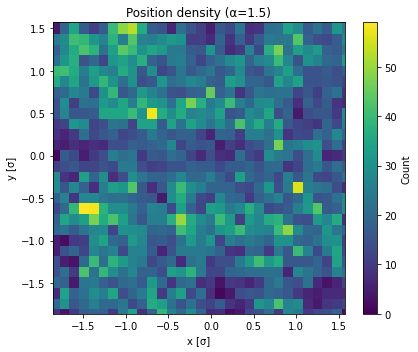

In [67]:
fig, ax = plt.subplots(figsize=(6, 5))
_, _, _, im = ax.hist2d(data['x'], data['y'], bins=60, cmap='viridis') #, vmin=0, vmax=100)
fig.colorbar(im, ax=ax, label='Count')
ax.set_xlabel('x [σ]')
ax.set_ylabel('y [σ]')
ax.set_ylim([x_arr[0], x_arr[-1]])
ax.set_xlim([x_arr[0], x_arr[-1]])
ax.set_title(f'Position density (α={alpha})')
fig.tight_layout()
fig.savefig('density_heatmap.png', dpi=150)

In [68]:
# fetch the predicted and true force along the trajectory
Forces_inferred_x = []
Forces_inferred_y = []
Forces_true_x = []
Forces_true_y = []
x_0,y_0 = 0,0
kappa_x,kappa_y = kappa0,kappa0
rel_errors = []
data_eval = data[data['frame'] < 2000]

# before the loop
all_true_x = [force_environment_NonLinear(x,y,kappa_x,kappa_y,x_0,y_0,alpha,L)[0] 
              for x,y in zip(data_eval['x'], data_eval['y'])]
all_true_y = [force_environment_NonLinear(x,y,kappa_x,kappa_y,x_0,y_0,alpha,L)[1] 
              for x,y in zip(data_eval['x'], data_eval['y'])]
rms_force = np.sqrt(np.mean(np.array(all_true_x)**2 + np.array(all_true_y)**2))
epsilon_reg = 0.05 * rms_force

for i in range(len(data_eval['x'])):
    x = data_eval['x'][i]
    y = data_eval['y'][i]
    F_env_infer_x,F_env_infer_y = get_force_environment(model, x, y)*tau_mem0*gamma0
    F_env_true_x,F_env_true_y = force_environment_NonLinear(x,y,kappa_x,kappa_y,x_0,y_0,alpha,L)
    Forces_inferred_x.append(F_env_infer_x)
    Forces_inferred_y.append(F_env_infer_y)
    Forces_true_x.append(F_env_true_x)
    Forces_true_y.append(F_env_true_y)
    err_x = F_env_infer_x - F_env_true_x
    err_y = F_env_infer_y - F_env_true_y
    err_norm = np.add(err_x**2,err_y**2)
    true_force_mag = np.add(F_env_true_x**2,F_env_true_y**2)
    if true_force_mag > 0.3*0.3:
       rel_errors.append(err_norm/true_force_mag)

    # err_mag = np.sqrt(err_x**2 + err_y**2)
    # true_mag = np.sqrt(F_env_true_x**2 + F_env_true_y**2)
    # # Normalise by true mag + small fraction of RMS force across dataset
    # #rms_force = np.sqrt(np.mean(np.array(Forces_true_x)**2 + np.array(Forces_true_y)**2))
    # #epsilon_reg = 0.05 * rms_force  # 5% of typical force scale
    # rel_errors.append(err_mag / (true_mag + epsilon_reg))
    
print("median rel error",np.median(rel_errors))
print("mean rel error",np.mean(rel_errors))

median rel error 0.06267942565509896
mean rel error 0.0839437495742559


In [102]:
name = f"modelGradF_OD_persistent_pairwise_alpha{alpha}_epsilon{epsilon}_tauInit{np.round(tau_mem0,1)}_seed{seed}_kappa{kappa0}_Gamma{gamma0}_Tau{tau_mem0}Sig1.1N100seed{seed}_Temp{temp}_NumFrames{numframes}_Epochs{NumEpochs}_3SwishNorm"
name = f"modelGradF_OD_persistent_pairwise_alpha{alpha}_epsilon{epsilon}_tauInit{np.round(tau_mem0,1)}_seed{seed}_kappa{kappa0}_Gamma{gamma0}_Tau{tau_mem0}Sig1.1N100seed{seed}_Temp{temp}_NumFrames{numframes}_Epochs{NumEpochs}_3Tanh_NoFenv"

save_model(model, datasave + name, history=history)


#save_model(model, datasave + name, history=history)

Model weights saved to: //Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/PersistentCells/PyTorch/models/NonLinearSweep/modelGradF_OD_persistent_pairwise_alpha2.0_epsilon0.0_tauInit10_seed3_kappa0.5_Gamma1_Tau10Sig1.1N100seed3_Temp0.1_NumFrames300_Epochs100_3Tanh_NoFenv.pt
Model config saved to:  //Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/PersistentCells/PyTorch/models/NonLinearSweep/modelGradF_OD_persistent_pairwise_alpha2.0_epsilon0.0_tauInit10_seed3_kappa0.5_Gamma1_Tau10Sig1.1N100seed3_Temp0.1_NumFrames300_Epochs100_3Tanh_NoFenv_config.json
Normalisation stats saved to: //Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/PersistentCells/PyTorch/models/NonLinearSweep/modelGradF_OD_persistent_pairwise_alpha2.0_epsilon0.0_tauInit10_seed3_kappa0.5_Gamma1_Tau10Sig1.1N100seed3_Temp0.1_NumFrames300_Epochs100_3Tanh_NoFenv_norm.json
History saved to: //Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/PersistentCells/PyTorch/models/NonLinearSweep/modelGradF_OD_

In [57]:
def save_model(model, filepath, history=None):
    if not filepath.endswith('.pt'):
        filepath = filepath + '.pt'

    # --- weights ---
    torch.save(model.state_dict(), filepath)
    print(f"Model weights saved to: {filepath}")

    # --- architecture config ---
    # Read hidden_dim from env_net (always present) rather than interaction_net (optional)
    hidden_dim = model.env_net[0].out_features
    config = {
        "hidden_dim":       int(hidden_dim),
        "tau_init":         float(model.tau_raw.detach().cpu()),
        "has_interaction":  hasattr(model, 'interaction_net'),
    }
    config_path = filepath.replace('.pt', '_config.json')
    with open(config_path, 'w') as f:
        json.dump(config, f, indent=2)
    print(f"Model config saved to:  {config_path}")

    # --- normalisation stats ---
    def _to_list(v):
        if isinstance(v, np.ndarray):
            return v.tolist()
        return float(v)

    norm = {
        "r_mean": _to_list(getattr(model, "r_mean", 0.0)),
        "r_std":  _to_list(getattr(model, "r_std",  1.0)),
        "y_mean": _to_list(getattr(model, "y_mean", np.array([0.0, 0.0]))),
        "y_std":  _to_list(getattr(model, "y_std",  np.array([1.0, 1.0]))),
        "x_mean": _to_list(getattr(model, "x_mean", np.array([0.0, 0.0]))),
        "x_std":  _to_list(getattr(model, "x_std",  1.0)),
    }
    norm_path = filepath.replace('.pt', '_norm.json')
    with open(norm_path, 'w') as f:
        json.dump(norm, f, indent=2)
    print(f"Normalisation stats saved to: {norm_path}")

    # --- history ---
    if history is not None:
        history_path = filepath.replace('.pt', '_history.json')
        clean = {}
        for k, v in history.items():
            if isinstance(v, (list, tuple)):
                clean[k] = [float(x) if not isinstance(x, str) else x for x in v]
            else:
                clean[k] = float(v) if not isinstance(v, str) else v
        with open(history_path, 'w') as f:
            json.dump(clean, f, indent=2)
        print(f"History saved to: {history_path}")


def load_model(filepath, hidden_dim=None, tau_init=1.0, device=None):
    if not filepath.endswith('.pt'):
        filepath = filepath + '.pt'

    if device is None:
        device = torch.device('cpu')

    # --- architecture config ---
    config_path = filepath.replace('.pt', '_config.json')
    try:
        with open(config_path, 'r') as f:
            config = json.load(f)
        hidden_dim = hidden_dim or config["hidden_dim"]
        tau_init   = config.get("tau_init", tau_init)
        print(f"Loaded config from: {config_path}  (hidden_dim={hidden_dim})")
    except FileNotFoundError:
        if hidden_dim is None:
            raise ValueError(
                f"No config file at {config_path} and hidden_dim not provided. "
                "Re-save with the updated save_model, or pass hidden_dim explicitly."
            )
        print(f"No config file found; using hidden_dim={hidden_dim}, tau_init={tau_init}")

    # --- reconstruct and load ---
    model = ForceGNN(hidden_dim=hidden_dim, tau_init=tau_init)
    state_dict = torch.load(filepath, map_location=device)
    model.load_state_dict(state_dict)
    print(f"Weights loaded from: {filepath}")

    # --- normalisation stats ---
    norm_path = filepath.replace('.pt', '_norm.json')
    try:
        with open(norm_path, 'r') as f:
            norm = json.load(f)
        model.r_mean = float(norm.get("r_mean", 0.0))
        model.r_std  = float(norm.get("r_std",  1.0)) or 1.0
        model.y_mean = np.array(norm.get("y_mean", [0.0, 0.0]), dtype=np.float32)
        model.y_std  = norm.get("y_std", 1.0)
        if isinstance(model.y_std, list):
            model.y_std = np.array(model.y_std, dtype=np.float32)
        else:
            model.y_std = float(model.y_std) or 1.0
        model.x_mean = np.array(norm.get("x_mean", [0.0, 0.0]), dtype=np.float32)
        model.x_std  = float(norm.get("x_std",  1.0)) or 1.0
        print(f"Normalisation restored: r_mean={model.r_mean:.6g}, r_std={model.r_std:.6g}")
    except FileNotFoundError:
        print(f"No normalisation file at {norm_path}; using defaults.")

    model.to(device)
    model.eval()
    print(f"  hidden_dim={hidden_dim}, tau={float(model.tau_raw.detach()):.6f}")
    return model

## these are the true pairwise and environment forces on this dataset


## Evaluate model, find $R^2$

In [199]:
def evaluate_model(model, test_data, verbose=True):
    test_predictions_masked = []
    test_targets_masked = []
    index_map = []  # (frame_idx, node_idx) for each masked row

    total_nodes = 0
    masked_nodes = 0

    model.eval()
    with torch.no_grad():
        for frame_idx, data_point in enumerate(test_data):
            predictions = model(
                torch.tensor(data_point['nodes']),
                torch.tensor(data_point['edges']),
                torch.tensor(data_point['edge_feat'])
            ).cpu().numpy()

            targets = data_point['targets']
            if isinstance(targets, torch.Tensor):
                targets = targets.cpu().numpy()

            if 'mask' in data_point:
                mask = data_point['mask']
                if isinstance(mask, torch.Tensor):
                    mask = mask.cpu().numpy()
            else:
                mask = np.ones(len(predictions), dtype=np.float32)

            mask_indices = mask == 1.0
            #mask_indices = mask.astype(bool)

            masked_pred = predictions[mask_indices]
            masked_targ = targets[mask_indices]

            test_predictions_masked.append(masked_pred)
            test_targets_masked.append(masked_targ)

            # record original indices
            node_ids = np.where(mask_indices)[0]
            index_map.extend([(frame_idx, int(n)) for n in node_ids])

            total_nodes  += len(predictions)
            masked_nodes += int(np.sum(mask_indices))

    if len(test_predictions_masked) > 0:
        test_predictions_flat = np.vstack(test_predictions_masked)
        test_targets_flat     = np.vstack(test_targets_masked)
        num_masked_nodes      = len(test_predictions_flat)

        if num_masked_nodes > 0:
            squared_errors = (test_predictions_flat - test_targets_flat) ** 2
            test_mse_x = np.mean(squared_errors[:, 0])
            test_mse_y = np.mean(squared_errors[:, 1])
            test_mse   = np.mean(squared_errors)
            test_mae   = np.mean(np.abs(test_predictions_flat - test_targets_flat))
        else:
            test_mse_x = test_mse_y = test_mse = test_mae = 0.0
    else:
        test_predictions_flat = np.zeros((0, 2), dtype=np.float32)
        test_targets_flat     = np.zeros((0, 2), dtype=np.float32)
        index_map        = []
        num_masked_nodes = 0
        test_mse_x = test_mse_y = test_mse = test_mae = 0.0

    if verbose:
        print(f"\nTest Set Evaluation (masked nodes only):")
        print(f"  Total nodes in test set: {total_nodes}")
        print(f"  Masked nodes (mask=1): {masked_nodes} ({100*masked_nodes/total_nodes:.1f}%)")
        print(f"  MSE (x-direction): {test_mse_x:.6f} (on {num_masked_nodes:.0f} masked nodes)")
        print(f"  MSE (y-direction): {test_mse_y:.6f} (on {num_masked_nodes:.0f} masked nodes)")
        print(f"  MSE (overall): {test_mse:.6f} (on {num_masked_nodes:.0f} masked nodes)")
        print(f"  MAE: {test_mae:.6f} (on {num_masked_nodes:.0f} masked nodes)")

    return {
        'mse':              test_mse,
        'mse_x':            test_mse_x,
        'mse_y':            test_mse_y,
        'mae':              test_mae,
        'predictions':      test_predictions_flat,
        'targets':          test_targets_flat,
        'index_map':        index_map,
        'num_masked_nodes': num_masked_nodes,
        'total_nodes':      total_nodes,
    }

In [200]:
evaluation = evaluate_model(model,train_data,verbose = True)
predictions = evaluation['predictions']
targets = evaluation['targets']
rsq_ax = 1-evaluation['mse_x']/np.mean((targets[:,0]-np.mean(targets[:,0]))**2)
rsq_ay = 1-evaluation['mse_y']/np.mean((targets[:,1]-np.mean(targets[:,1]))**2)
print(f"R^2 for ax: {rsq_ax:.4f}")
print(f"R^2 for ay: {rsq_ay:.4f}")
print(f"Average R^2: {(rsq_ax+rsq_ay)/2:.4f}")


Test Set Evaluation (masked nodes only):
  Total nodes in test set: 20900
  Masked nodes (mask=1): 20800 (99.5%)
  MSE (x-direction): 0.966401 (on 20800 masked nodes)
  MSE (y-direction): 0.976005 (on 20800 masked nodes)
  MSE (overall): 0.971203 (on 20800 masked nodes)
  MAE: 0.785658 (on 20800 masked nodes)
R^2 for ax: 0.0317
R^2 for ay: 0.0347
Average R^2: 0.0332


In [203]:
y_std = float(model.y_std)
rsq_ax = 1 - (evaluation['mse_x'] * y_std**2) / np.var(targets[:,0] * y_std)
rsq_ay = 1 - (evaluation['mse_y'] * y_std**2) / np.var(targets[:,1] * y_std)
print(f"R^2 for ax: {rsq_ax:.4f}")
print(f"R^2 for ay: {rsq_ay:.4f}")
print(f"Average R^2: {(rsq_ax+rsq_ay)/2:.4f}")

R^2 for ax: 0.0317
R^2 for ay: 0.0347
Average R^2: 0.0332


In [204]:
print("Var(targets):", np.var(targets))
print("Var(predictions):", np.var(predictions))
print("MSE:", evaluation['mse'])

Var(targets): 1.004575
Var(predictions): 0.032526765
MSE: 0.9712032


## Query environmental force

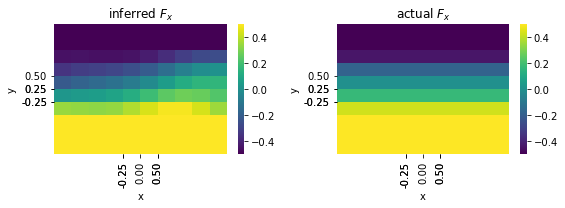

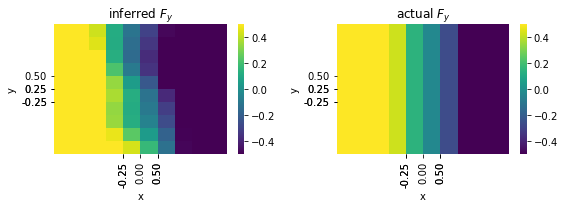

In [205]:
fig,ax = plt.subplots(1,2,figsize = (8,3))
x_ticks = np.linspace(-0.5,0.5,5)
y_ticks = np.linspace(-0.5,0.5,5)
x_tick_indices = [np.argmin(np.abs(x_arr - val)) for val in x_ticks]
y_tick_indices = [np.argmin(np.abs(y_arr - val)) for val in y_ticks]

# Create heatmaps
sns.heatmap(F_env_infer[:,:,0], ax=ax[0], cmap='viridis',
            xticklabels=[f'{x:.2f}' for x in x_ticks],
            yticklabels=[f'{y:.2f}' for y in y_ticks],vmin=-kappa_x,vmax = kappa_x)

sns.heatmap(F_env_true[:,:,0], ax=ax[1], cmap='viridis',
            xticklabels=[f'{x:.2f}' for x in x_ticks],
            yticklabels=[f'{y:.2f}' for y in y_ticks],vmin=-kappa_x,vmax = kappa_x)

# Set tick positions
for i in range(2):
    ax[i].set_xticks(x_tick_indices)
    ax[i].set_xticklabels([f'{x:.2f}' for x in x_ticks])
    ax[i].set_yticks(y_tick_indices)
    ax[i].set_yticklabels([f'{y:.2f}' for y in y_ticks])


ax[0].invert_yaxis()
ax[1].invert_yaxis()
ax[0].set_title(r'inferred $F_x$')
ax[1].set_title(r'actual $F_x$')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
fig.tight_layout()
fig,ax = plt.subplots(1,2,figsize = (8,3))
sns.heatmap(F_env_infer[:,:,1], ax=ax[0], cmap='viridis',
            xticklabels=[f'{x:.2f}' for x in x_ticks],
            yticklabels=[f'{y:.2f}' for y in y_ticks],vmin=-kappa_x,vmax = kappa_x)

sns.heatmap(F_env_true[:,:,1], ax=ax[1], cmap='viridis',
            xticklabels=[f'{x:.2f}' for x in x_ticks],
            yticklabels=[f'{y:.2f}' for y in y_ticks],vmin=-kappa_x,vmax = kappa_x)
ax[0].invert_yaxis()
ax[1].invert_yaxis()
for i in range(2):
    ax[i].set_xticks(x_tick_indices)
    ax[i].set_xticklabels([f'{x:.2f}' for x in x_ticks])
    ax[i].set_yticks(y_tick_indices)
    ax[i].set_yticklabels([f'{y:.2f}' for y in y_ticks])
ax[0].set_title(r'inferred $F_y$')
ax[1].set_title(r'actual $F_y$')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
fig.tight_layout()

In [206]:
import torch_inference_sims
importlib.reload(torch_inference_sims)
from torch_inference_sims import *

In [207]:
def estimate_noise_magnitude(model, test_data):
    all_residuals = []
    all_masks = []

    model.eval()
    with torch.no_grad():
        for data_point in test_data:
            node_features = torch.tensor(data_point['nodes'],     dtype=torch.float32)
            edge_indices  = torch.tensor(data_point['edges'],     dtype=torch.long)
            edge_features = torch.tensor(data_point['edge_feat'], dtype=torch.float32)

            Y_pred = model(node_features, edge_indices, edge_features).cpu().numpy()  # (N, 2)

            Y_true = data_point['targets']
            if isinstance(Y_true, torch.Tensor):
                Y_true = Y_true.cpu().numpy()

            resid = Y_true - Y_pred  # (N, 2)
            all_residuals.append(resid)

            if 'mask' in data_point:
                mask = data_point['mask']
                if isinstance(mask, torch.Tensor):
                    mask = mask.cpu().numpy()
                all_masks.append(mask)
            else:
                all_masks.append(np.ones(len(resid), dtype=np.float32))

    all_residuals = np.vstack(all_residuals)
    all_masks     = np.concatenate(all_masks)

    mask_indices     = all_masks == 1.0
    masked_residuals = all_residuals[mask_indices]

    if len(masked_residuals) == 0:
        print("Warning: No masked nodes found in test data for noise estimation")
        return {
            "per_dim_var":  np.array([0.0, 0.0]),
            "per_dim_std":  np.array([0.0, 0.0]),
            "overall_rms":  0.0,
            "num_samples":  0,
            "num_frames":   len(test_data),
            "mean_residual": np.array([0.0, 0.0]),
        }

    num_samples = len(masked_residuals)
    mean_r      = np.mean(masked_residuals, axis=0)
    var_r       = np.sum((masked_residuals - mean_r)**2, axis=0) / (num_samples - 1) if num_samples > 1 else np.zeros(2)
    std_r       = np.sqrt(var_r)
    overall_rms = np.sqrt(np.mean(np.sum(masked_residuals**2, axis=1)))

    return {
        "per_dim_var":        var_r,
        "per_dim_std":        std_r,
        "overall_rms":        float(overall_rms),
        "num_samples":        num_samples,
        "num_frames":         len(test_data),
        "mean_residual":      mean_r,
        "sum_residuals_sq_x": np.sum(masked_residuals[:, 0]**2),
        "sum_residuals_sq_y": np.sum(masked_residuals[:, 1]**2),
    }

def evaluate_model_frames(model, test_data, verbose=True):
    rows = []

    model.eval()
    with torch.no_grad():
        for frame_idx, data_point in enumerate(test_data):
            frame_id = data_point.get('frame', frame_idx)

            node_features = torch.tensor(data_point['nodes'],     dtype=torch.float32)
            edge_indices  = torch.tensor(data_point['edges'],     dtype=torch.long)
            edge_features = torch.tensor(data_point['edge_feat'], dtype=torch.float32)

            predictions = model(node_features, edge_indices, edge_features).cpu().numpy()

            targets = data_point['targets']
            if isinstance(targets, torch.Tensor):
                targets = targets.cpu().numpy()

            nodes = data_point['nodes']

            if 'mask' in data_point:
                mask = data_point['mask']
                if isinstance(mask, torch.Tensor):
                    mask = mask.cpu().numpy()
            else:
                mask = np.ones(len(predictions), dtype=np.float32)

            if 'particle_ids' in data_point:
                node_ids = data_point['particle_ids']
            else:
                node_ids = np.arange(len(predictions))

            mask_indices = mask == 1.0

            theta_pred   = np.arctan2(predictions[:, 1], predictions[:, 0])
            theta_true   = np.arctan2(targets[:, 1],     targets[:, 0])
            errors_theta = np.abs(theta_pred - theta_true)
            errors_x     = predictions[:, 0] - targets[:, 0]
            errors_y     = predictions[:, 1] - targets[:, 1]
            errors       = np.sqrt(errors_x**2 + errors_y**2)

            num_neighbors_arr = data_point['num_neighbors']
            nn_r_arr          = data_point['nn_r']

            for i in range(len(predictions)):
                if mask_indices[i]:
                    rows.append({
                        'frame':         frame_id,
                        'node_id':       int(node_ids[i]) if hasattr(node_ids[i], '__int__') else node_ids[i],
                        'x':             float(nodes[i, 0]),
                        'y':             float(nodes[i, 1]),
                        'vx':            float(nodes[i, 2]),
                        'vy':            float(nodes[i, 3]),
                        'num_neighbors': float(num_neighbors_arr[i]),
                        'nn_r':          float(nn_r_arr[i]),
                        'error':         float(errors[i]),
                        'error_theta':   float(errors_theta[i]),
                        'error_x':       float(errors_x[i]),
                        'error_y':       float(errors_y[i]),
                        'pred_x':        float(predictions[i, 0]),
                        'pred_y':        float(predictions[i, 1]),
                        'target_x':      float(targets[i, 0]),
                        'target_y':      float(targets[i, 1]),
                    })

    df = pd.DataFrame(rows)

    if verbose:
        if len(df) > 0:
            print(f"\nFrame-based Evaluation:")
            print(f"  Total rows:     {len(df)}")
            print(f"  Unique frames:  {df['frame'].nunique()}")
            print(f"  Unique nodes:   {df['node_id'].nunique()}")
            print(f"  Mean error:     {df['error'].mean():.6f}")
            print(f"  Median error:   {df['error'].median():.6f}")
            print(f"  Std error:      {df['error'].std():.6f}")
        else:
            print("\nFrame-based Evaluation: No data (all nodes may have been masked out)")

    return df

{'per_dim_var': array([1.0013269, 1.0099194], dtype=float32), 'per_dim_std': array([1.0006633, 1.0049474], dtype=float32), 'overall_rms': 1.4183722734451294, 'num_samples': 4400, 'num_frames': 44, 'mean_residual': array([-0.00205492,  0.03137764], dtype=float32), 'sum_residuals_sq_x': 4404.857, 'sum_residuals_sq_y': 4446.976}
1.0
1.0


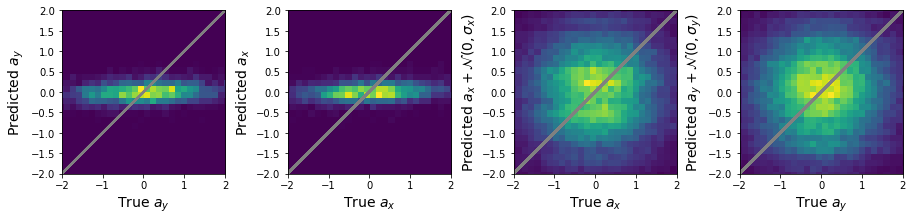

In [208]:
# visualise the y_pred vs y_true and compare against a noise-floor reference:
# targets vs targets + N(0, sigma). A perfect model, given the inferred noise,
# would reproduce the distribution in the right panels. If the left panels look
# tighter OR similar to the right panels, the model is at/near the noise floor.
evaluation = evaluate_model(model, val_data, verbose=False)
predictions = evaluation['predictions']
targets = evaluation['targets']
Overall_noise = estimate_noise_magnitude(model, val_data)
print(Overall_noise)

rng = np.random.default_rng(0)
n_draws = 20  # multiple draws per target so the reference heatmap isn't sparser

sigma_x, sigma_y = Overall_noise['per_dim_std']

# Noise-floor reference: tile targets and perturb by independent Gaussian noise.
ax_pred_rep = np.repeat(predictions[:, 0], n_draws)
ay_pred_rep = np.repeat(predictions[:, 1], n_draws)
ax_true_rep = np.repeat(targets[:, 0], n_draws)
ay_true_rep = np.repeat(targets[:, 1], n_draws)
ax_noisy = ax_pred_rep + rng.normal(0.0, sigma_x, size=ax_pred_rep.shape)
ay_noisy = ay_pred_rep + rng.normal(0.0, sigma_y, size=ay_pred_rep.shape)

fig, ax = plt.subplots(1, 4, figsize=(16, 3))
vmin, vmax = -3, 3
bins = 40
rng_range = [[vmin, vmax], [vmin, vmax]]

amin = 0.0
amax = 600
a_mag = np.sqrt(targets[:, 0]**2 + targets[:, 1]**2)
valid = a_mag > amin
fraction_valid = np.sum(valid) / len(valid)
print(fraction_valid)
valid = (a_mag > amin) & (a_mag < amax)
fraction_valid = np.sum(valid) / len(valid)
print(fraction_valid)

# (0) true a_y vs predicted a_y
h, _, _ = np.histogram2d(targets[:, 1], predictions[:, 1], bins=bins, range=rng_range)
ax[0].imshow(h.T, extent=[vmin, vmax, vmin, vmax], origin='lower',
             cmap='viridis', aspect='equal')
ax[0].set_xlabel(r'True $a_y$', fontsize=14)
ax[0].set_ylabel(r'Predicted $a_y$', fontsize=14)

# (1) true a_x vs predicted a_x
h, _, _ = np.histogram2d(targets[:, 0], predictions[:, 0], bins=bins, range=rng_range)
ax[1].imshow(h.T, extent=[vmin, vmax, vmin, vmax], origin='lower',
             cmap='viridis', aspect='equal')
ax[1].set_xlabel(r'True $a_x$', fontsize=14)
ax[1].set_ylabel(r'Predicted $a_x$', fontsize=14)
ax[1].plot(targets[valid, 1],targets[valid, 1],color = 'grey',linewidth = 2)
ax[0].plot(targets[valid, 0],targets[valid, 0],color = 'grey',linewidth = 2)
ax[2].plot(targets[valid, 1],targets[valid, 1],color = 'grey',linewidth = 2)
ax[3].plot(targets[valid, 0],targets[valid, 0],color = 'grey',linewidth = 2)
# (2) NOISE FLOOR: true a_x vs (true a_x + sigma_x * N(0,1))
h, _, _ = np.histogram2d(ax_true_rep, ax_noisy, bins=bins, range=rng_range)
ax[2].imshow(h, extent=[vmin, vmax, vmin, vmax], origin='lower',
             cmap='viridis', aspect='equal')
ax[2].set_ylabel(r'Predicted $a_x + \mathcal{N}(0,\sigma_x)$', fontsize=14)
ax[2].set_xlabel(r'True $a_x$', fontsize=14)

# (3) NOISE FLOOR: true a_y vs (true a_y + sigma_y * N(0,1))
h, _, _ = np.histogram2d(ay_true_rep, ay_noisy, bins=bins, range=rng_range)
ax[3].imshow(h, extent=[vmin, vmax, vmin, vmax], origin='lower',
             cmap='viridis', aspect='equal')
ax[3].set_ylabel(r'Predicted $a_y + \mathcal{N}(0,\sigma_y)$', fontsize=14)
ax[3].set_xlabel(r'True $a_y$', fontsize=14)
ax[1].set_xlim([-2,2])
ax[1].set_ylim([-2,2])
ax[0].set_xlim([-2,2])
ax[0].set_ylim([-2,2])
ax[2].set_xlim([-2,2])
ax[2].set_ylim([-2,2])
ax[3].set_xlim([-2,2])
ax[3].set_ylim([-2,2])
fig.subplots_adjust(wspace=0.05)
plt.show()

1.0


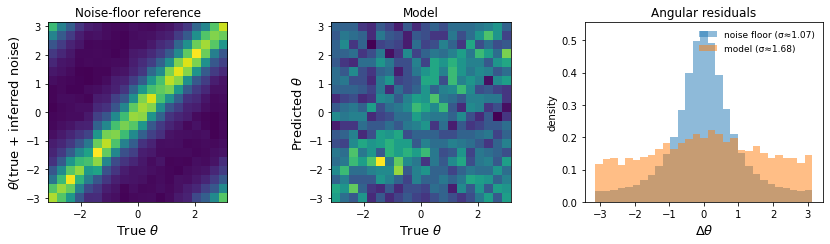

In [209]:
# Noise-floor reference for the angle plot.
# Compares true theta against theta(true + inferred noise), NOT theta(pred + noise).
# This shows the angular scatter you would see even for a perfect model, given the
# inferred per-component noise (sigma_x, sigma_y). Compare this panel directly
# against your existing "true theta vs predicted theta" heatmap.

rng = np.random.default_rng(0)
n_draws = 20  # multiple noise draws per point to smooth the reference distribution

sigma_x, sigma_y = Overall_noise['per_dim_std']


ax_true = targets[:, 0]
ay_true = targets[:, 1]

# Tile targets n_draws times and add independent Gaussian noise per component.
ax_tiled = np.repeat(ax_true, n_draws)
ay_tiled = np.repeat(ay_true, n_draws)
ax_noisy = ax_tiled + rng.normal(0.0, sigma_x, size=ax_tiled.shape)
ay_noisy = ay_tiled + rng.normal(0.0, sigma_y, size=ay_tiled.shape)

theta_true       = np.arctan2(ay_true,  ax_true)
theta_true_rep   = np.repeat(theta_true, n_draws)
theta_true_noisy = np.arctan2(ay_noisy, ax_noisy)

# Magnitude mask (angle is ill-defined for tiny |a|) — match your earlier amin choice.
amin = 0.0
a_mag_rep = np.sqrt(ax_tiled**2 + ay_tiled**2)
#valid = a_mag_rep > amin

amin = 0.0
amax = 6.0
#a_mag = np.sqrt(targets[:, 0]**2 + targets[:, 1]**2)
valid = (a_mag_rep > amin) & (a_mag_rep < amax)
fraction_valid = np.sum(valid) / len(valid)
print(fraction_valid)


# Also prepare the predicted-theta heatmap for side-by-side comparison.
theta_pred = np.arctan2(predictions[:, 1], predictions[:, 0])
a_mag = np.sqrt(targets[:, 0]**2 + targets[:, 1]**2)
valid_pred = (a_mag > amin) & (a_mag < amax)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.5))

# (0) Noise-floor reference: true vs true+noise
h0, xe, ye = np.histogram2d(theta_true_rep[valid], theta_true_noisy[valid],
                            bins=20, range=[[-np.pi, np.pi], [-np.pi, np.pi]])
ax[0].imshow(h0.T, extent=[-np.pi, np.pi, -np.pi, np.pi],
             origin='lower', cmap='viridis', aspect='equal')
ax[0].set_xlabel(r'True $\theta$', fontsize=13)
ax[0].set_ylabel(r'$\theta$(true + inferred noise)', fontsize=13)
ax[0].set_title('Noise-floor reference')

# (1) Model performance: true vs predicted
h1, _, _ = np.histogram2d(theta_true[valid_pred], theta_pred[valid_pred],
                          bins=20, range=[[-np.pi, np.pi], [-np.pi, np.pi]])
ax[1].imshow(h1.T, extent=[-np.pi, np.pi, -np.pi, np.pi],
             origin='lower', cmap='viridis', aspect='equal')
ax[1].set_xlabel(r'True $\theta$', fontsize=13)
ax[1].set_ylabel(r'Predicted $\theta$', fontsize=13)
ax[1].set_title('Model')

# (2) Residual distributions overlaid (wrapped to [-pi, pi]).
def wrap(d):
    return (d + np.pi) % (2 * np.pi) - np.pi

dtheta_ref   = wrap(theta_true_noisy[valid] - theta_true_rep[valid])
dtheta_model = wrap(theta_pred[valid_pred] - theta_true[valid_pred])
bins = np.linspace(-np.pi, np.pi, 30)
ax[2].hist(dtheta_ref,   bins=bins, density=True, alpha=0.5,
           label=f'noise floor (σ≈{np.std(dtheta_ref):.2f})')
ax[2].hist(dtheta_model, bins=bins, density=True, alpha=0.5,
           label=f'model (σ≈{np.std(dtheta_model):.2f})')
ax[2].set_xlabel(r'$\Delta\theta$', fontsize=13)
ax[2].set_ylabel('density')
ax[2].legend(frameon=False, fontsize=9)
ax[2].set_title('Angular residuals')

fig.tight_layout()
plt.show()

In [210]:
# Run this before the _summarise call to see what's happening
mask_values = []
for dp in val_data:
    if 'mask' in dp:
        mask_values.extend(dp['mask'].tolist() if hasattr(dp['mask'], 'tolist') else list(dp['mask']))

mask_arr = np.array(mask_values)
print(f"Total mask entries: {len(mask_arr)}")
print(f"Unique values in mask: {np.unique(mask_arr)}")
print(f"dtype: {mask_arr.dtype}")
print(f"Count == 1.0 : {np.sum(mask_arr == 1.0)}")
print(f"Count == 1   : {np.sum(mask_arr == 1)}")
print(f"Count  > 0   : {np.sum(mask_arr > 0)}")
print(f"Sample values: {mask_arr[:20]}")

Total mask entries: 4400
Unique values in mask: [ True]
dtype: bool
Count == 1.0 : 4400
Count == 1   : 4400
Count  > 0   : 4400
Sample values: [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True]


In [211]:
print(f"Dataset frame range: {_df['frame'].min()} to {_df['frame'].max()}")
print(f"_is_edge_start True count: {_is_edge_start.sum()}")
print(f"_is_edge_end True count:   {_is_edge_end.sum()}")
print(f"Short track count:         {(_track_length < MIN_TRACK_LENGTH).sum()}")
print(f"Sample _first_frame: {_first_frame.unique()[:5]}")
print(f"Sample _last_frame:  {_last_frame.unique()[:5]}")

NameError: name '_df' is not defined

In [212]:
Data_Fine_UD = evaluate_model_frames(model,__,verbose = False)


Using 29700 / 29700 rows  (100.0%) for noise distribution analysis.

Moments of the residual distribution (normalised acceleration units):
eta_x shape: (29700,), eta_y shape: (29700,)
Any NaN: False, Any Inf: False
eta_x : n=29700  mean=-0.0056  std=0.9847  skew=-0.003  excess kurtosis=-0.013
        Anderson–Darling A² = 0.26  (critical at 1% sig level: 1.09; larger ⇒ reject Gaussian)
eta_y : n=29700  mean=+0.0106  std=0.9899  skew=+0.020  excess kurtosis=+0.024
        Anderson–Darling A² = 0.39  (critical at 1% sig level: 1.09; larger ⇒ reject Gaussian)


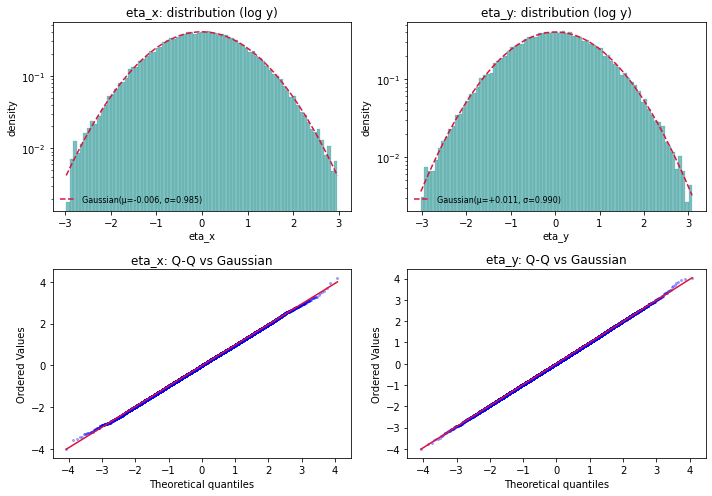

1.0011987673954317


In [213]:
# ------------------------------------------------------------------
# Noise analysis Step 1: distribution of η = target − prediction
# in normalised acceleration units.
# Self-contained: computes the "honest cells" filter inline.
# ------------------------------------------------------------------
from scipy import stats as _scistats

_df = Data_Fine_UD

# --- Compute filter inline (no dependency on previous cells) -----
MIN_TRACK_LENGTH = 10
_first_frame = _df.groupby('node_id')['frame'].transform('min')
_last_frame  = _df.groupby('node_id')['frame'].transform('max')
_track_length = _last_frame - _first_frame + 1
_dataset_first = _df['frame'].min()
_dataset_last  = _df['frame'].max()
_is_edge_start = (_first_frame == _dataset_first)
_is_edge_end   = (_last_frame  == _dataset_last)
#mask = (~_is_edge_start) & (~_is_edge_end) & (_track_length >= MIN_TRACK_LENGTH)
mask = _track_length >= MIN_TRACK_LENGTH
sub = _df[mask]
print(f"Using {mask.sum()} / {len(_df)} rows  "
      f"({100*mask.mean():.1f}%) for noise distribution analysis.")

# Per-row noise: η = target − prediction, in normalised units.
eta_x = (sub['target_x'] - sub['pred_x']).to_numpy()
eta_y = (sub['target_y'] - sub['pred_y']).to_numpy()

# --- Moments and normality stats --------------------------------
def _summarise(label, e):
    e = np.asarray(e).ravel()
    n = len(e)
    
    if n == 0:
        print(f"{label:6s}: no samples (empty array — check mask)")
        return np.nan, np.nan
    if n < 8:   # Anderson-Darling is unreliable below ~8 samples
        print(f"{label:6s}: n={n}  too few samples for Anderson-Darling test")
        mu, sd = np.mean(e), np.std(e, ddof=1)
        return mu, sd

    mu  = np.mean(e)
    sd  = np.std(e, ddof=1)
    sk  = _scistats.skew(e)
    ku  = _scistats.kurtosis(e, fisher=True)
    ad  = _scistats.anderson(e, dist='norm')
    print(f"{label:6s}: n={n}  mean={mu:+.4f}  std={sd:.4f}  "
          f"skew={sk:+.3f}  excess kurtosis={ku:+.3f}")
    print(f"        Anderson–Darling A² = {ad.statistic:.2f}  "
          f"(critical at 1% sig level: {ad.critical_values[-1]:.2f}; "
          f"larger ⇒ reject Gaussian)")
    return mu, sd

print("\nMoments of the residual distribution (normalised acceleration units):")
print(f"eta_x shape: {eta_x.shape}, eta_y shape: {eta_y.shape}")
print(f"Any NaN: {np.any(np.isnan(eta_x))}, Any Inf: {np.any(np.isinf(eta_x))}")
mu_x, sd_x = _summarise('eta_x', eta_x)
mu_y, sd_y = _summarise('eta_y', eta_y)

# --- Plot: histograms with Gaussian overlay + Q-Q plots ---------
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for ax_i, (label, e, mu, sd) in enumerate([('eta_x', eta_x, mu_x, sd_x),
                                            ('eta_y', eta_y, mu_y, sd_y)]):
    ax = axes[0, ax_i]
    bins = np.linspace(np.percentile(e, 0.1), np.percentile(e, 99.9), 80)
    ax.hist(e, bins=bins, density=True, color='teal', alpha=0.5,
            edgecolor='teal', lw=0.3)
    xs = np.linspace(bins[0], bins[-1], 400)
    gauss = np.exp(-0.5 * ((xs - mu) / sd)**2) / (sd * np.sqrt(2 * np.pi))
    ax.plot(xs, gauss, '--', color='crimson', lw=1.5,
            label=f'Gaussian(μ={mu:+.3f}, σ={sd:.3f})')
    ax.set_xlabel(label)
    ax.set_ylabel('density')
    ax.legend(frameon=False, fontsize=8)
    ax.set_yscale('log')
    ax.set_title(f'{label}: distribution (log y)')

    ax = axes[1, ax_i]
    _scistats.probplot(e, dist='norm', plot=ax)
    ax.get_lines()[0].set_markersize(2)
    ax.get_lines()[0].set_alpha(0.3)
    ax.get_lines()[1].set_color('crimson')
    ax.set_title(f'{label}: Q-Q vs Gaussian')

fig.tight_layout()
plt.show()
print(sub['target_x'].std())

Using 29700 rows from 100 particles.
Computed autocorrelations across 100 trajectories.


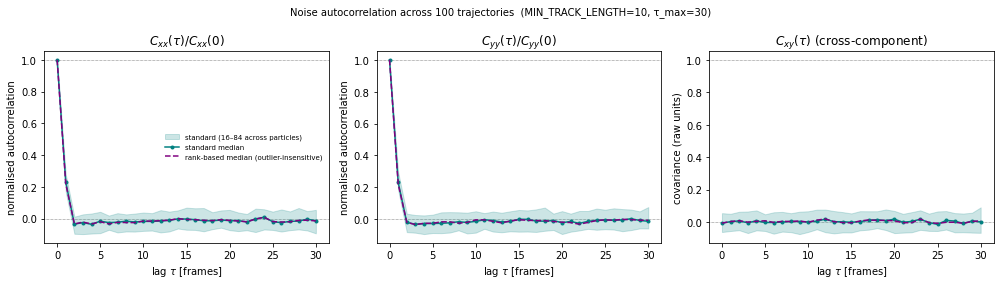


Key-lag summary (median across particles):
  τ=  0: C_xx=+1.000  C_yy=+1.000  C_xy=-0.007    (n_particles=100)
  τ=  1: C_xx=+0.230  C_yy=+0.231  C_xy=+0.003    (n_particles=100)
  τ=  2: C_xx=-0.034  C_yy=-0.021  C_xy=+0.007    (n_particles=100)
  τ=  5: C_xx=-0.016  C_yy=-0.027  C_xy=-0.002    (n_particles=100)
  τ= 10: C_xx=-0.017  C_yy=-0.014  C_xy=+0.001    (n_particles=100)
  τ= 20: C_xx=-0.012  C_yy=-0.023  C_xy=+0.018    (n_particles=100)


In [214]:
# ------------------------------------------------------------------
# Noise analysis Step 2: autocorrelation function of η = target − pred.
# Per particle, then averaged across particles. Computed as both the
# standard estimator (sensitive to heavy tails) and a rank-based
# version (insensitive to tails). Three components: C_xx, C_yy, C_xy.
# Self-contained — recomputes the "honest cells" filter inline.
# ------------------------------------------------------------------
from scipy import stats as _scistats

_df = Data_Fine_UD

# --- Filter: same as Step 1 -------------------------------------
MIN_TRACK_LENGTH = 10
TAU_MAX = 30
MIN_PARTICLES_PER_LAG = 5     # discard lag estimates with fewer than this many particles

_first_frame = _df.groupby('node_id')['frame'].transform('min')
_last_frame  = _df.groupby('node_id')['frame'].transform('max')
_track_length = _last_frame - _first_frame + 1
_dataset_first = _df['frame'].min()
_dataset_last  = _df['frame'].max()
_is_edge_start = (_first_frame == _dataset_first)
_is_edge_end   = (_last_frame  == _dataset_last)
#mask = (~_is_edge_start) & (~_is_edge_end) & (_track_length >= MIN_TRACK_LENGTH)
mask = _track_length >= MIN_TRACK_LENGTH

sub = _df[mask].copy()
sub['eta_x'] = sub['target_x'] - sub['pred_x']
sub['eta_y'] = sub['target_y'] - sub['pred_y']
print(f"Using {len(sub)} rows from {sub['node_id'].nunique()} particles.")

# --- Per-particle autocorrelation -------------------------------
def _trajectory_autocorr(eta_a, eta_b, tau_max):
    """
    Compute C_ab(τ) = ⟨ η_a(t) η_b(t+τ) ⟩ along a single trajectory.
    Returns array of length tau_max+1 (NaN where trajectory too short).
    Mean of each series is subtracted first (per-trajectory zero-mean).
    """
    a = eta_a - np.mean(eta_a)
    b = eta_b - np.mean(eta_b)
    n = len(a)
    out = np.full(tau_max + 1, np.nan)
    for tau in range(tau_max + 1):
        if n - tau < 2:
            break
        out[tau] = np.mean(a[: n - tau] * b[tau:])
    return out

# Containers: rows = particles, cols = τ.
particle_ids = []
C_xx_per = []
C_yy_per = []
C_xy_per = []
C_xx_rank_per = []
C_yy_rank_per = []
C_xy_rank_per = []

for pid, traj in sub.sort_values(['node_id', 'frame']).groupby('node_id'):
    # Frame continuity check: only keep contiguous tracks for clean lag definition.
    frames = traj['frame'].to_numpy()
    if not np.all(np.diff(frames) == 1):
        # If the trajectory has gaps, split into contiguous runs and use the
        # longest. (Could alternatively use all runs; the simplest honest choice.)
        breaks = np.where(np.diff(frames) != 1)[0] + 1
        runs = np.split(np.arange(len(frames)), breaks)
        run = max(runs, key=len)
        traj = traj.iloc[run]
        if len(traj) < MIN_TRACK_LENGTH:
            continue

    ex = traj['eta_x'].to_numpy()
    ey = traj['eta_y'].to_numpy()
    rx = _scistats.rankdata(ex)               # rank-based: insensitive to outliers
    ry = _scistats.rankdata(ey)

    C_xx_per.append(_trajectory_autocorr(ex, ex, TAU_MAX))
    C_yy_per.append(_trajectory_autocorr(ey, ey, TAU_MAX))
    C_xy_per.append(_trajectory_autocorr(ex, ey, TAU_MAX))
    C_xx_rank_per.append(_trajectory_autocorr(rx, rx, TAU_MAX))
    C_yy_rank_per.append(_trajectory_autocorr(ry, ry, TAU_MAX))
    C_xy_rank_per.append(_trajectory_autocorr(rx, ry, TAU_MAX))
    particle_ids.append(pid)

C_xx_per = np.array(C_xx_per)
C_yy_per = np.array(C_yy_per)
C_xy_per = np.array(C_xy_per)
C_xx_rank_per = np.array(C_xx_rank_per)
C_yy_rank_per = np.array(C_yy_rank_per)
C_xy_rank_per = np.array(C_xy_rank_per)

print(f"Computed autocorrelations across {len(particle_ids)} trajectories.")

# --- Aggregate across particles ---------------------------------
def _agg(per_particle):
    """Returns mean, median, 16th, 84th percentiles, n at each lag (NaN-safe)."""
    out = {}
    out['mean']   = np.nanmean(per_particle, axis=0)
    out['median'] = np.nanmedian(per_particle, axis=0)
    out['lo']     = np.nanpercentile(per_particle, 16, axis=0)
    out['hi']     = np.nanpercentile(per_particle, 84, axis=0)
    out['n']      = np.sum(np.isfinite(per_particle), axis=0)
    return out

# Normalise C(τ) by C(0) within each particle so all curves start at 1
# (for the autocorrelation panels). For the cross-correlation we don't
# normalise — its scale is meaningful.
def _normalise_per_particle(per_particle):
    norm = per_particle[:, 0:1].copy()
    norm[norm == 0] = np.nan
    return per_particle / norm

def _normalise_cross(per_particle_xy, per_particle_xx, per_particle_yy):
    """Pearson-style normalisation: C_xy(τ) / sqrt(C_xx(0) * C_yy(0)) per particle."""
    norm = np.sqrt(per_particle_xx[:, 0:1] * per_particle_yy[:, 0:1])
    norm[norm <= 0] = np.nan
    return per_particle_xy / norm

C_xy_norm    = _normalise_cross(C_xy_per,      C_xx_per,      C_yy_per)
C_xy_rk_norm = _normalise_cross(C_xy_rank_per, C_xx_rank_per, C_yy_rank_per)

agg_xy    = _agg(C_xy_norm)
agg_xy_rk = _agg(C_xy_rk_norm)

C_xx_norm     = _normalise_per_particle(C_xx_per)
C_yy_norm     = _normalise_per_particle(C_yy_per)
C_xx_rk_norm  = _normalise_per_particle(C_xx_rank_per)
C_yy_rk_norm  = _normalise_per_particle(C_yy_rank_per)

agg_xx     = _agg(C_xx_norm)
agg_yy     = _agg(C_yy_norm)
#agg_xy     = _agg(C_xy_per)        # not normalised
agg_xx_rk  = _agg(C_xx_rk_norm)
agg_yy_rk  = _agg(C_yy_rk_norm)
#agg_xy_rk  = _agg(C_xy_rank_per)

# --- Plot ---------------------------------------------------------
taus = np.arange(TAU_MAX + 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

def _plot_panel(ax, agg_std, agg_rk, title, ylabel, normalise_to_one=True):
    valid = agg_std['n'] >= MIN_PARTICLES_PER_LAG

    # Standard estimator: median + 16/84 band (median is more robust than mean).
    ax.fill_between(taus[valid], agg_std['lo'][valid], agg_std['hi'][valid],
                    color='teal', alpha=0.2, zorder=2,
                    label='standard (16–84 across particles)')
    ax.plot(taus[valid], agg_std['median'][valid], '-o', color='teal',
            markersize=3, lw=1.5, zorder=3, label='standard median')

    # Rank-based: dashed line, no band (would clutter).
    ax.plot(taus[valid], agg_rk['median'][valid], '--', color='purple',
            lw=1.5, zorder=4, label='rank-based median (outlier-insensitive)')

    ax.axhline(0, color='k', lw=0.5, ls=':', zorder=1)
    if normalise_to_one:
        ax.axhline(1, color='k', lw=0.5, ls=':', zorder=1)
    ax.set_xlabel(r'lag $\tau$ [frames]')
    ax.set_ylabel(ylabel)
    ax.set_title(title)

_plot_panel(axes[0], agg_xx,    agg_xx_rk,
            r'$C_{xx}(\tau) / C_{xx}(0)$', 'normalised autocorrelation',
            normalise_to_one=True)
_plot_panel(axes[1], agg_yy,    agg_yy_rk,
            r'$C_{yy}(\tau) / C_{yy}(0)$', 'normalised autocorrelation',
            normalise_to_one=True)
_plot_panel(axes[2], agg_xy,    agg_xy_rk,
            r'$C_{xy}(\tau)$ (cross-component)',
            'covariance (raw units)', normalise_to_one=True)

axes[0].legend(frameon=False, fontsize=7, loc='best')
fig.suptitle(f'Noise autocorrelation across {len(particle_ids)} trajectories  '
             f'(MIN_TRACK_LENGTH={MIN_TRACK_LENGTH}, τ_max={TAU_MAX})',
             fontsize=10)
fig.tight_layout()
plt.show()

# --- Quick numerical summary at key lags ------------------------
def _at(agg, tau):
    return agg['median'][tau], agg['n'][tau]

print(f"\nKey-lag summary (median across particles):")
for tau in [0, 1, 2, 5, 10, 20]:
    if tau > TAU_MAX:
        continue
    m_xx, n_xx = _at(agg_xx, tau)
    m_yy, n_yy = _at(agg_yy, tau)
    m_xy, n_xy = _at(agg_xy, tau)
    print(f"  τ={tau:3d}: C_xx={m_xx:+.3f}  C_yy={m_yy:+.3f}  "
          f"C_xy={m_xy:+.3f}    (n_particles={n_xx})")